In [8]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Plot settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Pranav\Downloads\Amdox internship\Medicine prediction\financial_fraud_detection_dataset.csv"
)

df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

df.head()

Shape: (5000, 14)

Columns:
Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date',
       'Transaction_Amount', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Location', 'Is_International', 'Previous_Transactions',
       'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword',
       'Fraudulent'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   object 
 1   Customer_ID            5000 non-null   object 
 2   Transaction_Date       5000 non-null   object 
 3   Transaction_Amount     5000 non-null   float64
 4   Merchant_Category      5000 non-null   object 
 5   Payment_Method         5000 non-null   object 
 6   Device_Type            5000 non-null   object 
 7   Location               5000 non-null   object 
 8   Is_International

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


# 1. Dataset Overview

This dataset contains financial transaction records including transaction amount, merchant category, payment method, device type, transaction location, and fraud labels. The objective is to identify potentially fraudulent transactions using machine learning techniques.

In [4]:
df.isnull().sum()

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64

In [5]:
df.isnull().sum().sum()

0

In [11]:
print(df.columns.tolist())

['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Fraudulent']


### Observation

No missing values were detected in the dataset. The data is complete and suitable for further analysis and model development.

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5000, 14)


In [13]:
df['Fraudulent'].value_counts()

Fraudulent
0    4518
1     482
Name: count, dtype: int64

In [15]:
df['Fraudulent'].value_counts(normalize=True)*100

Fraudulent
0    90.36
1     9.64
Name: proportion, dtype: float64

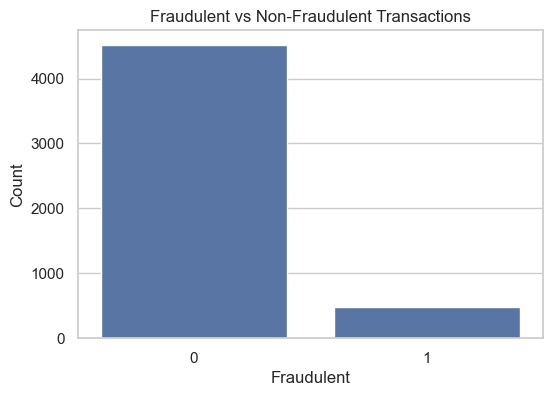

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Fraudulent'
)

plt.title("Fraudulent vs Non-Fraudulent Transactions")

plt.xlabel("Fraudulent")

plt.ylabel("Count")

plt.show()

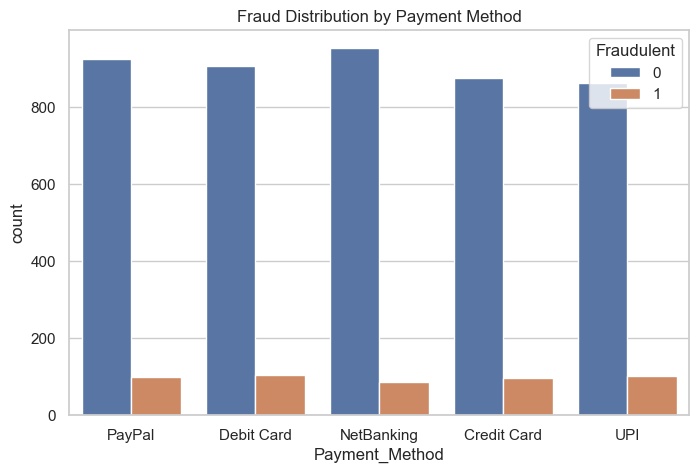

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Payment_Method',
    hue='Fraudulent'
)

plt.title("Fraud Distribution by Payment Method")

plt.show()

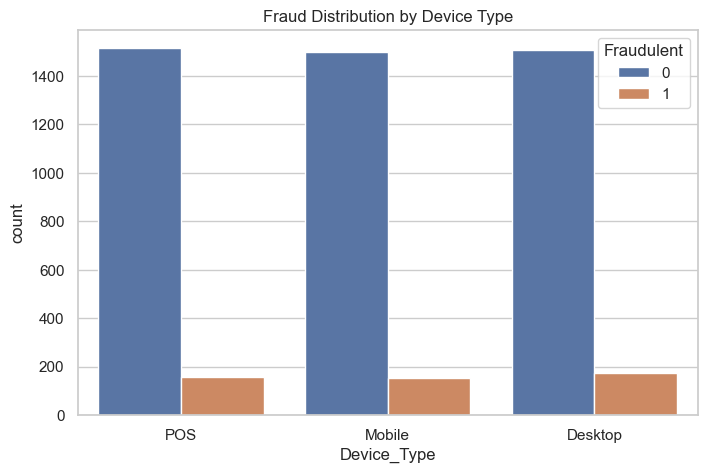

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Device_Type',
    hue='Fraudulent'
)

plt.title("Fraud Distribution by Device Type")

plt.show()

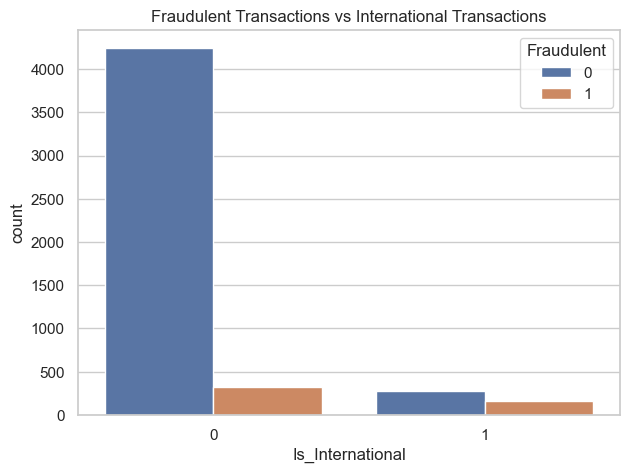

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Is_International',
    hue='Fraudulent'
)

plt.title("Fraudulent Transactions vs International Transactions")

plt.show()

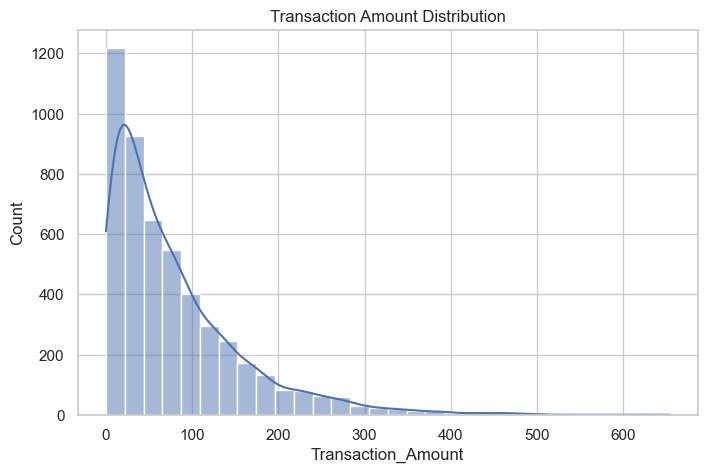

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Transaction_Amount'],
    bins=30,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

# Data Preprocessing

Machine learning models require numerical input. Therefore, categorical features are converted into numerical values using Label Encoding.

In [21]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

encoders = {}

for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le

df_ml.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,0,984,658,37.54,6,3,2,0,0,94,417.40,1492,0,0
1,1,276,4256,240.81,7,3,1,0,0,76,335.47,66,0,0
2,2,2936,2979,105.34,1,1,1,0,0,60,432.03,216,0,0
3,3,1668,2684,73.04,7,2,0,4,0,68,488.30,449,0,0
4,4,3364,1462,13.57,7,0,0,0,0,57,437.03,754,0,0


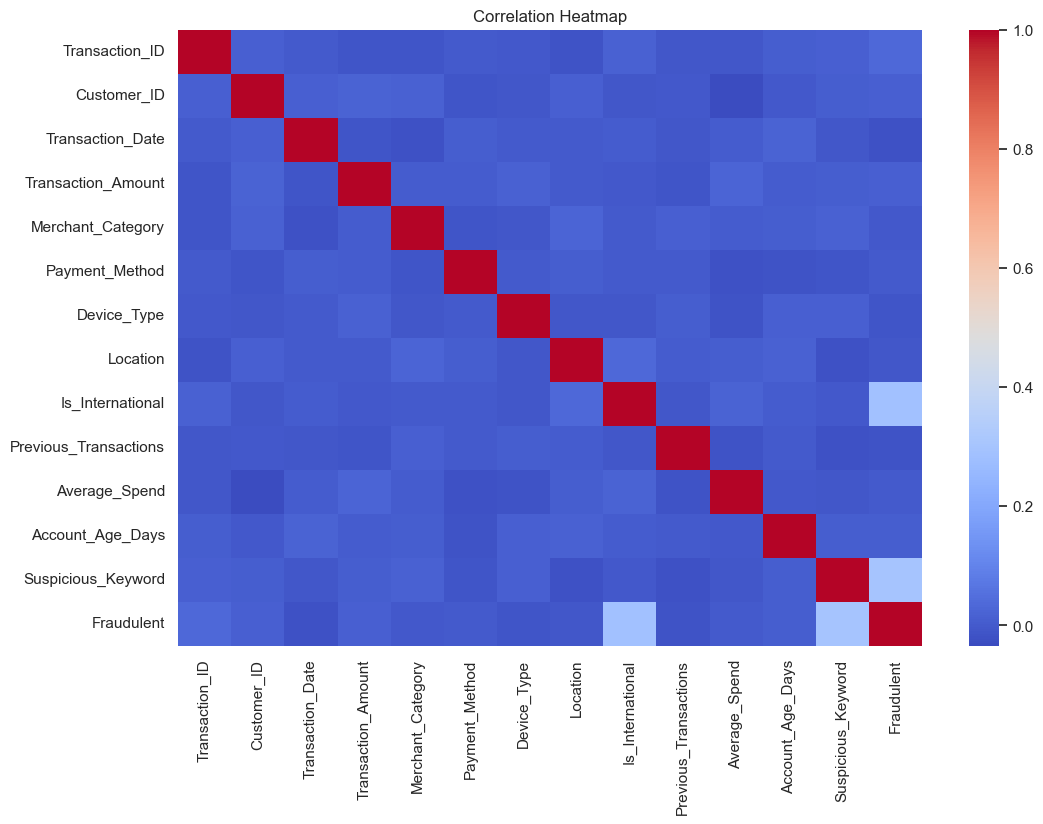

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_ml.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows relationships among variables. Features with stronger correlations may contribute more significantly to fraud detection.

In [23]:
X = df_ml.drop('Fraudulent', axis=1)

y = df_ml['Fraudulent']

print(X.shape)
print(y.shape)

(5000, 13)
(5000,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (4000, 13)
Testing: (1000, 13)


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [26]:
y_pred = rf_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 90.2 %


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       901
           1       0.53      0.09      0.16        99

    accuracy                           0.90      1000
   macro avg       0.72      0.54      0.55      1000
weighted avg       0.87      0.90      0.87      1000



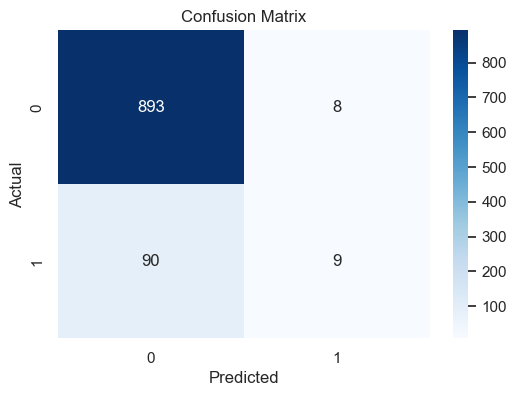

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

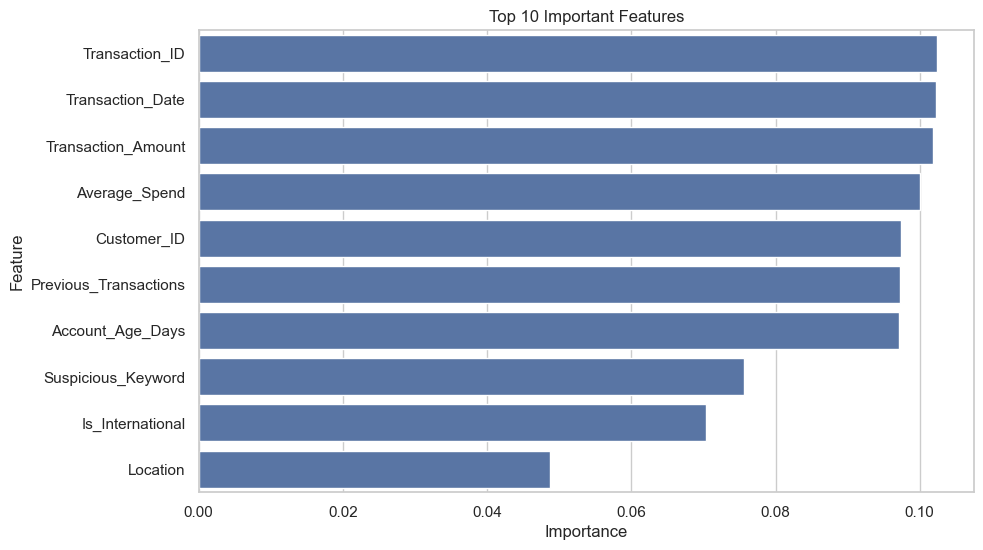

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

# Conclusion

This project focused on the development of a Financial Fraud Detection System using machine learning techniques. The dataset consisted of 5,000 transaction records containing information such as transaction amount, merchant category, payment method, device type, customer spending behavior, and fraud status.

During the Exploratory Data Analysis (EDA) phase, various patterns were identified in transaction behavior. Fraudulent transactions were observed across different payment methods, device types, and transaction locations. The analysis also highlighted the influence of customer spending patterns and transaction characteristics on fraud occurrence.

To prepare the data for machine learning, categorical variables were transformed into numerical values using Label Encoding. The dataset was then divided into training and testing sets to evaluate model performance objectively.

A Random Forest Classifier was trained to classify transactions as fraudulent or non-fraudulent. The model achieved an accuracy of 90.2%, demonstrating strong predictive capability and effective identification of suspicious transactions.

Overall, the project shows that machine learning can play a significant role in detecting fraudulent financial activities, reducing potential financial losses, and supporting secure digital transactions.

# Key Findings

- The dataset contained 5,000 transaction records with no missing values.
- Fraudulent transactions represented a smaller portion of the overall dataset.
- Fraud cases were observed across all payment methods and device types.
- International transactions showed a higher tendency toward fraudulent activity compared to domestic transactions.
- Transaction amount distribution was highly skewed, with most transactions involving smaller amounts.
- Random Forest successfully learned transaction patterns and achieved 90.2% prediction accuracy.
- Customer transaction history and spending behavior contributed significantly to fraud prediction.

# Business Impact

The implementation of a fraud detection model can provide several benefits to financial institutions and online payment platforms:

- Early identification of suspicious transactions.
- Reduction in financial losses caused by fraud.
- Improved customer trust and transaction security.
- Faster investigation of high-risk activities.
- Better risk management through automated fraud screening.
- Enhanced decision-making using data-driven insights.

# Future Scope

Although the current model achieved strong performance, several improvements can be implemented in future versions of the system:

- Develop a real-time fraud monitoring system using streaming transaction data.
- Integrate advanced anomaly detection techniques such as Isolation Forest and Autoencoders.
- Compare multiple machine learning models including XGBoost, LightGBM, and Gradient Boosting.
- Build an interactive Streamlit dashboard for live fraud monitoring and visualization.
- Implement risk scoring mechanisms for transaction prioritization.
- Incorporate additional customer behavioral features for improved prediction accuracy.
- Deploy the model as a web application or cloud-based service for practical business use.
- Explore deep learning approaches for large-scale fraud detection systems.

# Final Project Summary

This Financial Fraud Detection project successfully combined data analytics, visualization, and machine learning to identify fraudulent transactions. Through comprehensive exploratory analysis and predictive modeling, the system achieved an accuracy of 90.2%, demonstrating the effectiveness of machine learning in fraud prevention.

The project highlights how transaction data can be leveraged to detect suspicious activities, improve financial security, and support decision-making processes within organizations. The developed model provides a reliable foundation for future fraud detection systems and real-world financial monitoring applications.